## Imports das Bibliotecas

In [2]:
## Imports Geral
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import nltk
import numpy as np 

# Import para Visualização de Dados
from wordcloud import WordCloud

# Extração de Texto
from nltk.corpus import stopwords

# Importações de Metrica
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Preprocessamento
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# Modelos
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

import warnings

# Suprimir todos os warnings
warnings.filterwarnings("ignore")

# DESENVOLVER O MODELO SEM VIES 

# Analise dos dados

In [3]:
df = pd.read_csv("cor_da_justica.csv")
remover_colunas = ["Unnamed: 0", "uris.uriAutores", "uris.uriPropPrincipal",
                   "uris.uriUltimoRelator", "foto", "cpf", ]
df = df.drop(columns=remover_colunas)
df = df.dropna(subset=["ementa"])
df = df.drop_duplicates()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10790 entries, 0 to 11736
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   ementa                 10790 non-null  object
 1   ementaDetalhada        491 non-null    object
 2   ano                    10790 non-null  int64 
 3   keywords               5071 non-null   object
 4   nome                   10790 non-null  object
 5   sexo                   10790 non-null  object
 6   nascimento             10790 non-null  object
 7   local_nascimento       10790 non-null  object
 8   escolaridade           10531 non-null  object
 9   uris.uriPartido        10790 non-null  object
 10  ementa_principal       10790 non-null  object
 11  situacao               2068 non-null   object
 12  tipo                   2242 non-null   object
 13  keywords_principal     2219 non-null   object
 14  nome_partido           10790 non-null  object
 15  sigla_partido          1

In [4]:
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["ementaDetalhada"] if x["ementaDetalhada"] == str(x["ementaDetalhada"]) else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["ementa_principal"] if x["ementa_principal"] != str("vazio") else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["keywords"] if x["keywords"] == str(x["keywords"]) else x["ementa"] , axis=1)
df["ementa"] = df.apply(lambda x: x["ementa"] + ' ' +  x["keywords_principal"] if x["keywords_principal"] == str(x["keywords_principal"]) else x["ementa"] , axis=1)

In [5]:
df = df.drop(columns=["ementaDetalhada", "ementa_principal", 'keywords', 'keywords_principal'])

In [6]:
df["situacao"].loc[(df["situacao"] == "Aguardando Designação de Relator(a)" ) | (df["situacao"] == "Aguardando Parecer") | (df["situacao"] == "Aguardando Encaminhamento") | (df["situacao"] == "Aguardando Definição Encaminhamento") | (df["situacao"] == "Aguardando Recurso") | (df["situacao"] == "Aguardando Despacho de Arquivamento ") | (df["situacao"] == "Aguardando Deliberação")  | (df["situacao"] == "Aguardando Designação - Aguardando Devolução de Relator(a) que deixou de ser Membro") | (df["situacao"] == "Aguardando Análise de Parecer") | (df["situacao"] == "Arquivada") ] = "AGUARDANDO"
df["situacao"].loc[(df["situacao"] == "Tramitando em Conjunto" ) | (df["situacao"] == "Pronta para Pauta")] = "TRAMITANDO"
df["situacao"] = df["situacao"].fillna("RECUSADO")

In [7]:
df = df.drop(df[(df['cor'] == "#NE") | (
    df["cor"] == "#NE#") | (df["cor"] == "NÃO DIVULGÁVEL")].index).reset_index(drop=True)

df["cor"].loc[(df["cor"] == "AMARELA") | (df["cor"] == "INDÍGENA") | (df["cor"] == "PARDA") | (df["cor"] == "PRETA")] = "OUTROS"

In [8]:
df['cor'].value_counts()

cor
BRANCA    3421
OUTROS    1397
Name: count, dtype: int64

In [9]:
# # y_pred = model_LR.predict(X)
# # rng = np.random.default_rng(42)
# rng = np.random.default_rng(62)
# numbers = rng.random(len(df))
# balanceamento = [df.loc[df["cor"] == "BRANCA"].sample(1)  if i < prob_brancos else df.loc[df['cor'] == 'OUTROS'].sample(1) for i in numbers]
# df = pd.concat(balanceamento)


In [10]:
# df["nome"].value_counts().unique()
df["ementa"].count()

4818

In [11]:
cor = df["cor"].value_counts().reset_index()
cor["cor"].unique()
cor

,cor,count
0,BRANCA,3421
1,OUTROS,1397


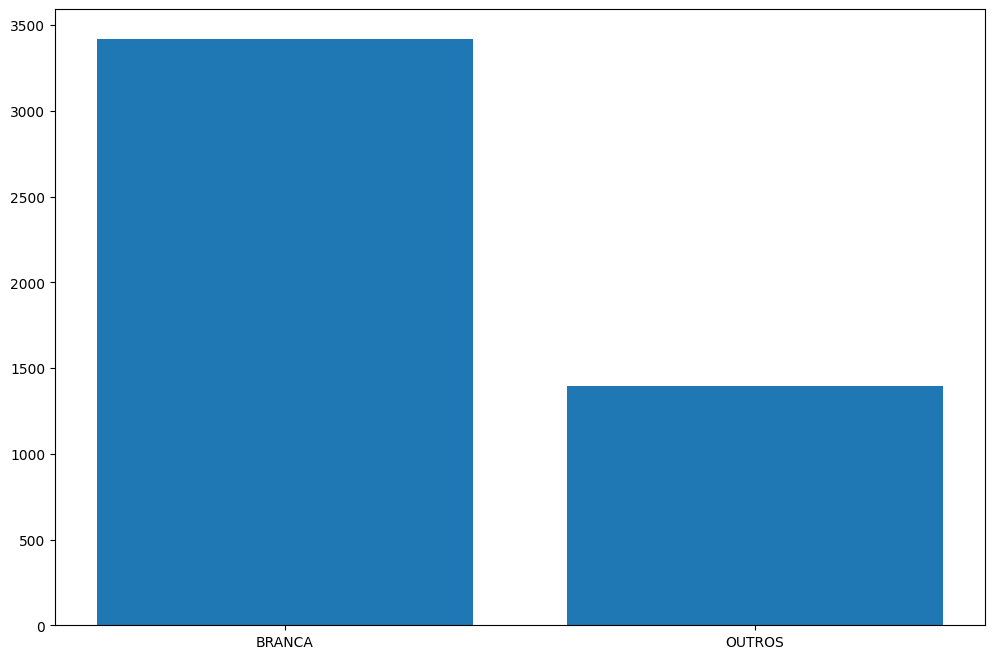

In [12]:
fx, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.bar(cor["cor"], height=cor["count"])
plt.show()

In [13]:
df["ementa"].dropna().count()

4818

## Bag Of Words

In [14]:
# nltk.download('stopwords')

In [15]:
df = df.dropna(subset=["ementa"]).reset_index(drop=True)

In [16]:
tf_idf = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
X = tf_idf.fit_transform(df["ementa"])
vocab = tf_idf.get_feature_names_out()
vocab = ' '.join(vocab)


## WORD CLOUD

In [17]:
le = LabelEncoder()

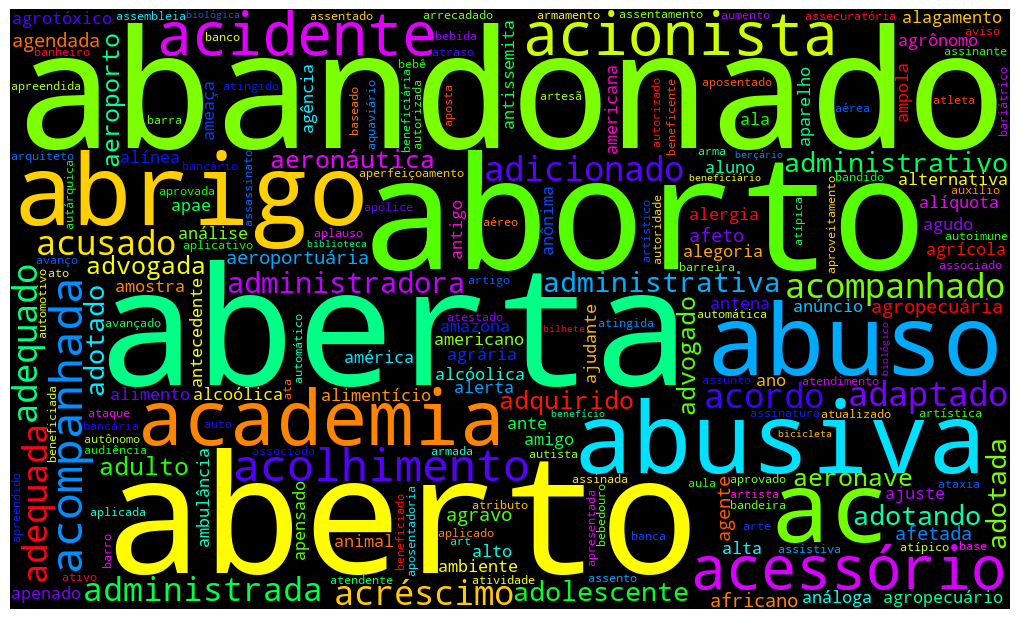

In [18]:
# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='black',
    colormap='gist_rainbow',
    min_font_size=10).generate(vocab)

plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

In [19]:
df_brancos = df[df["cor"] == "BRANCA"]
df_outros  = df[df["cor"] == "OUTROS"]




tf_idf_brancos = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )
tf_idf_outros = TfidfVectorizer(stop_words=(stopwords.words('portuguese')), ngram_range=(1,1) )


y_brancos = le.fit_transform(df_brancos["situacao"])
y_outros = le.fit_transform(df_outros["situacao"])


In [20]:
X_brancos = tf_idf_brancos.fit_transform(df_brancos["ementa"])
vocab_brancos = tf_idf_brancos.get_feature_names_out()
vocab_brancos = ' '.join(vocab_brancos)


In [21]:
X_outros = tf_idf.fit_transform(df_outros["ementa"])
vocab_outros = tf_idf.get_feature_names_out()
vocab_outros = ' '.join(vocab_outros)


## GRUPO 1: PESSOA DE COR DE PELE BRANCA

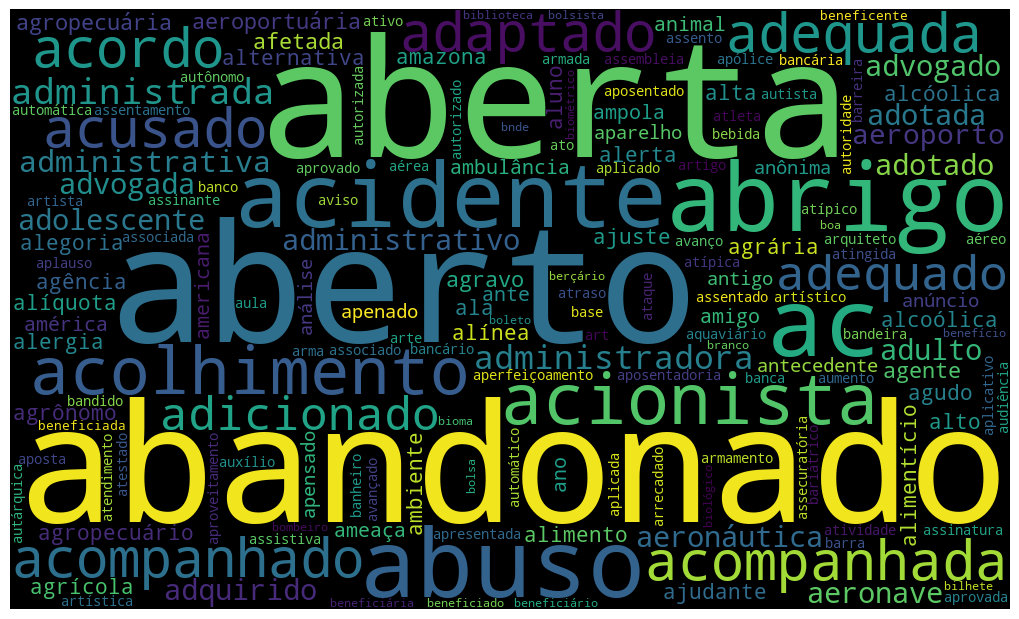

In [22]:

# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='black',
    min_font_size=10).generate(vocab_brancos)
plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

## GRUPO 2: PESSOA DE COR DE PELE DIFERENTES 

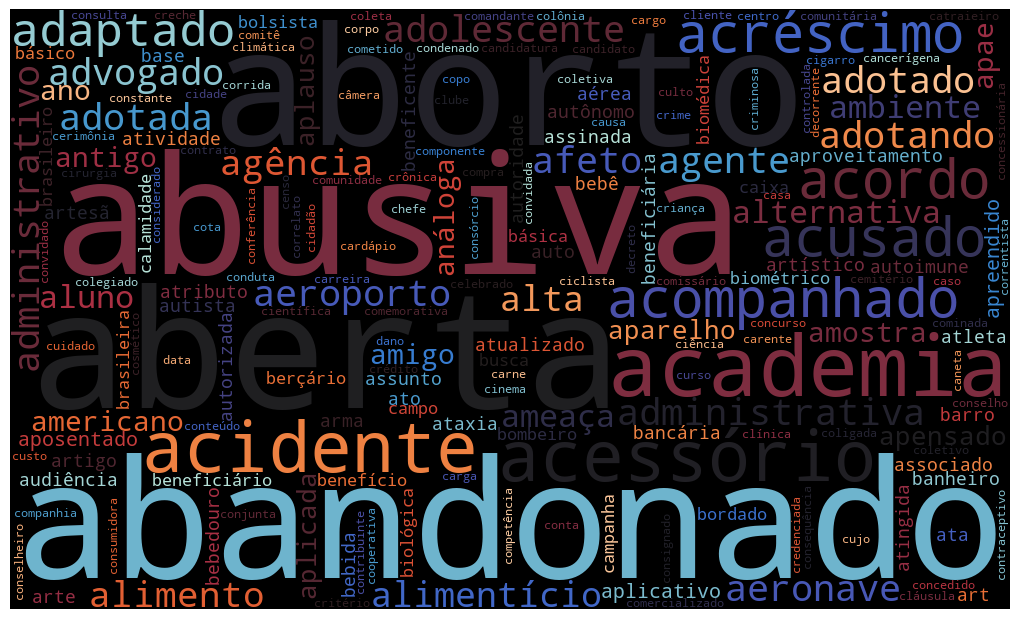

In [23]:

# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='black',
    colormap='icefire',
    min_font_size=10).generate(vocab_outros)
plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

# PCA

In [24]:
df['cor']

0       BRANCA
1       OUTROS
2       BRANCA
3       BRANCA
4       BRANCA
         ...  
4813    OUTROS
4814    BRANCA
4815    BRANCA
4816    BRANCA
4817    BRANCA
Name: cor, Length: 4818, dtype: object

In [25]:
le = LabelEncoder()

df["cor"] = le.fit_transform(df["cor"])
y = df["cor"]

In [26]:
y

0       0
1       1
2       0
3       0
4       0
       ..
4813    1
4814    0
4815    0
4816    0
4817    0
Name: cor, Length: 4818, dtype: int32

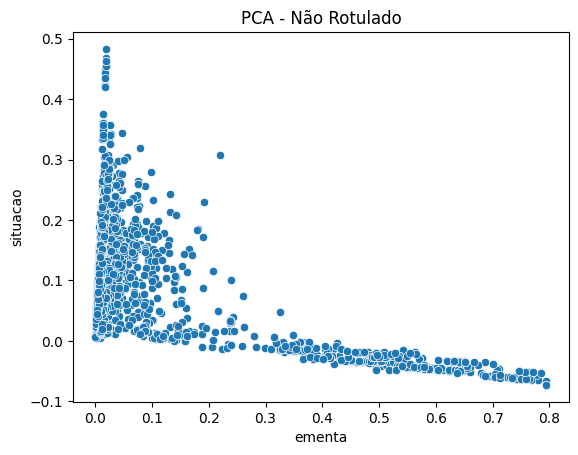

In [27]:
pca = TruncatedSVD(n_components=2)
X_pca = pca.fit_transform(X)
df_pca = pd.DataFrame(data=X_pca, columns=['ementa', 'situacao'])
df_pca["target"] = df["cor"].reset_index(drop=True)


sns.scatterplot(x='ementa', y="situacao", data=df_pca)
plt.title('PCA - Não Rotulado')
plt.show()

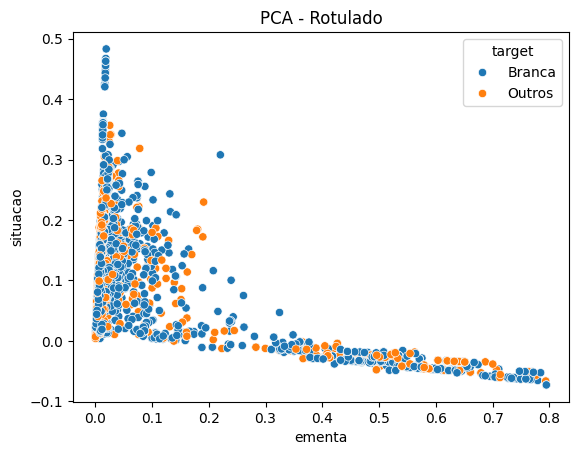

In [28]:
y_map = {0: 'Branca', 1: 'Outros'}

df_pca["target"] = df["cor"].map(y_map)

sns.scatterplot(x='ementa', y="situacao", hue="target", data=df_pca)
plt.title('PCA - Rotulado')
plt.show()

## Treino do Modelo

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
from imblearn.over_sampling import SMOTE

# transform the dataset
oversample = SMOTE()
X_train, y_train = oversample.fit_resample(X_train, y_train)

In [31]:
## Funçao para Avaliação dos Modelos

def evaluation_parametrics(name, y_test, y_pred):
    cm_test = confusion_matrix(y_test, y_pred)
    
    t1 = ConfusionMatrixDisplay(cm_test, display_labels=[
                                "Branca", 'Outros'])
    print("Classification Report for Data Test")
    print(classification_report(y_test, y_pred))
    t1.plot()

In [32]:
#K Fold

K = 5
kf = KFold(n_splits=K, shuffle=False) 

# Logistic Regression

In [33]:
model_LR = LogisticRegression(random_state=42, max_iter=1000, solver="liblinear", penalty="l2", C=3, tol=0.001)
cross_val_results_f1_scoreLR = cross_val_score(model_LR, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracyLR = cross_val_score(model_LR, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results_f1_scoreLR)


print("Media da Accuracy: ", cross_val_results_accuracyLR.mean())
print("Media da MACRO F1: ", cross_val_results_f1_scoreLR.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results_f1_scoreLR.std())

Resultado da Cross Validation:  [0.47116731 0.55042454 0.55525362 0.5471367  0.53599535]
Media da Accuracy:  0.7106610566047491
Media da MACRO F1:  0.531995505703479
Desvio Padrão da MACRO F1:  0.031067322691159544


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.80      0.80      0.80       698
           1       0.48      0.48      0.48       266

    accuracy                           0.71       964
   macro avg       0.64      0.64      0.64       964
weighted avg       0.71      0.71      0.71       964



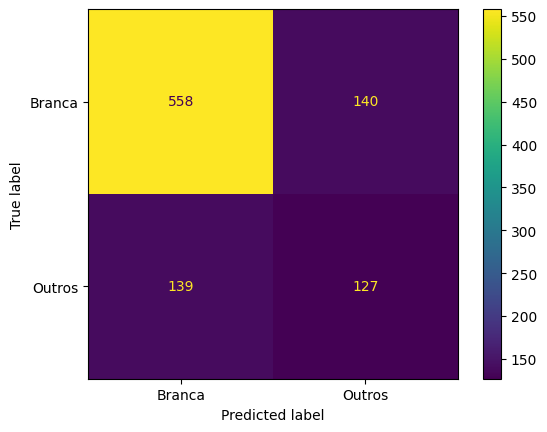

In [34]:
model_LR.fit(X_train, y_train)
y_pred = model_LR.predict(X_test)
evaluation_parametrics("Machine Learning - Logistic", y_test, y_pred)

# SGD Classifier

In [35]:
model_SGD = SGDClassifier(random_state=42, loss="squared_hinge", alpha=0.0001, learning_rate="constant", eta0=0.1, power_t=0.5, penalty="l2", tol=0.001, early_stopping=True, n_jobs=-1, class_weight="balanced")
cross_val_results_f1_scoreSGD = cross_val_score(model_SGD, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracySGD = cross_val_score(model_SGD, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results_f1_scoreSGD)

print("Media da Accuracy: ", cross_val_results_accuracySGD.mean())
print("Media da MACRO F1: ", cross_val_results_f1_scoreSGD.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results_f1_scoreSGD.std())

Resultado da Cross Validation:  [0.55518944 0.58055295 0.6042468  0.60724285 0.57995843]
Media da Accuracy:  0.6627193719488286
Media da MACRO F1:  0.5854380925262299
Desvio Padrão da MACRO F1:  0.01896358164368915


# K Neighbors Classifier

In [36]:
model_KNeighbors = KNeighborsClassifier(n_neighbors=5, weights="distance", algorithm="auto", leaf_size=50, p=2 )
cross_val_results_f1_scoreKN = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="f1_macro", )
cross_val_results_accuracyKN = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results_f1_scoreKN)

print("Media da Accuracy: ", cross_val_results_accuracyKN.mean())
print("Media da MACRO F1: ", cross_val_results_f1_scoreKN.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results_f1_scoreKN.std())

Resultado da Cross Validation:  [0.49679613 0.55599334 0.54910097 0.57505013 0.50265864]
Media da Accuracy:  0.6542053920364698
Media da MACRO F1:  0.5359198439997152
Desvio Padrão da MACRO F1:  0.030805320454774493


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.87      0.28      0.43       698
           1       0.32      0.89      0.47       266

    accuracy                           0.45       964
   macro avg       0.59      0.58      0.45       964
weighted avg       0.72      0.45      0.44       964



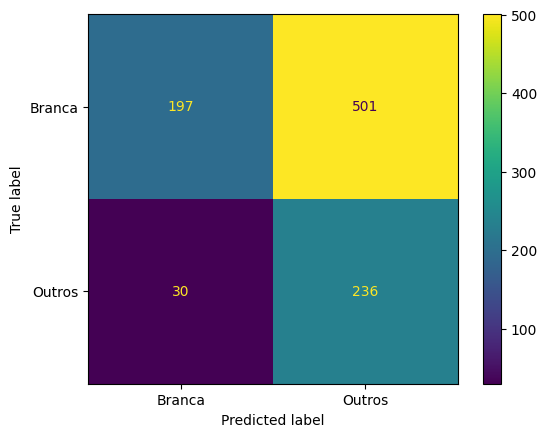

In [37]:
model_KNeighbors.fit(X_train, y_train)
y_pred = model_KNeighbors.predict(X_test)
evaluation_parametrics("Machine Learning - K Neighbors", y_test, y_pred)

# SVM (SUPPORT VECTOR MACHINE)

In [38]:
model_SVM = LinearSVC(random_state=42, loss='squared_hinge', max_iter=1000, penalty="l2", C=3, tol=0.0001, multi_class='ovr', dual=True, class_weight="balanced",  )
cross_val_results_f1_scoreSVM = cross_val_score(model_SVM, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracySVM = cross_val_score(model_SVM, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results_f1_scoreSVM)

print("Media da Accuracy: ", cross_val_results_accuracySVM.mean())
print("Media da MACRO F1: ", cross_val_results_f1_scoreSVM.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results_f1_scoreSVM.std())

Resultado da Cross Validation:  [0.5550907  0.58307074 0.6107293  0.59308669 0.59465698]
Media da Accuracy:  0.6697769763403609
Media da MACRO F1:  0.5873268824381477
Desvio Padrão da MACRO F1:  0.01839491939738655


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.80      0.81      0.80       698
           1       0.48      0.45      0.47       266

    accuracy                           0.71       964
   macro avg       0.64      0.63      0.64       964
weighted avg       0.71      0.71      0.71       964



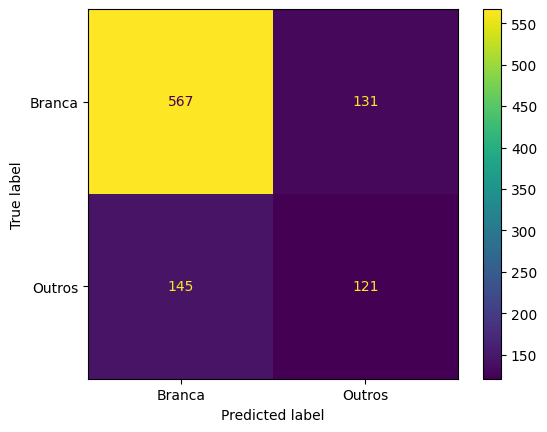

In [39]:
model_SVM.fit(X_train, y_train)
y_pred = model_SVM.predict(X_test)
evaluation_parametrics("Machine Learning - SVM", y_test, y_pred)

# Random Forest

In [40]:
model_Random_Forest = RandomForestClassifier(random_state=42, n_estimators=500, criterion="gini", max_features='sqrt', class_weight='balanced', n_jobs=-1, )
cross_val_results_f1_scoreRF = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracyRF = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="accuracy")


print("Resultado da Cross Validation: ", cross_val_results_f1_scoreRF)

print("Media da Accuracy: ", cross_val_results_accuracyRF.mean())
print("Media da MACRO F1: ", cross_val_results_f1_scoreRF.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results_f1_scoreRF.std())

Resultado da Cross Validation:  [0.42973807 0.51951832 0.51211423 0.54536871 0.57396807]
Media da Accuracy:  0.7160621415614242
Media da MACRO F1:  0.516141479453051
Desvio Padrão da MACRO F1:  0.04835559144911805


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.77      0.89      0.83       698
           1       0.53      0.31      0.39       266

    accuracy                           0.73       964
   macro avg       0.65      0.60      0.61       964
weighted avg       0.70      0.73      0.71       964



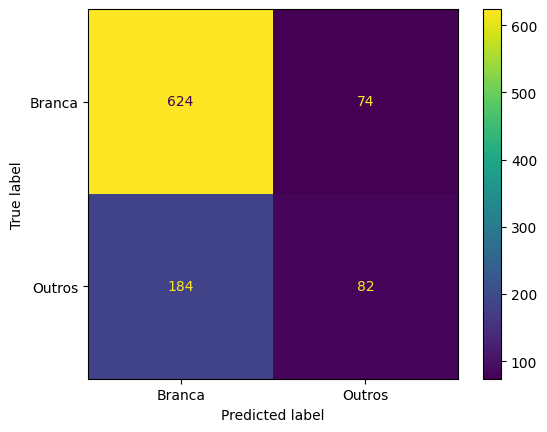

In [41]:
model_Random_Forest.fit(X_train, y_train)
y_pred = model_Random_Forest.predict(X_test)
evaluation_parametrics("Machine Learning - Random Forest", y_test, y_pred)

# Decision Tree

In [42]:
model_Decision_Tree = DecisionTreeClassifier(random_state=42, criterion="entropy", splitter="random", class_weight="balanced", ccp_alpha=0.0001)

cross_val_results_f1_scoreDT = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracyDT = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results_f1_scoreDT)

print("Media da Accuracy: ", cross_val_results_accuracyDT.mean())
print("Media da MACRO F1: ", cross_val_results_f1_scoreDT.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results_f1_scoreDT.std())

Resultado da Cross Validation:  [0.53045333 0.5141206  0.55545393 0.60291116 0.59367866]
Media da Accuracy:  0.6349219891159628
Media da MACRO F1:  0.5593235343972569
Desvio Padrão da MACRO F1:  0.0345598708465765


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.78      0.79      0.78       698
           1       0.42      0.41      0.42       266

    accuracy                           0.68       964
   macro avg       0.60      0.60      0.60       964
weighted avg       0.68      0.68      0.68       964



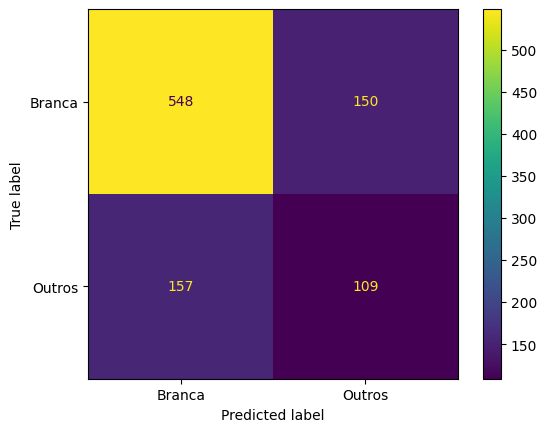

In [43]:
model_Decision_Tree.fit(X_train, y_train)
y_pred = model_Decision_Tree.predict(X_test)
evaluation_parametrics("Machine Learning - Decision Tree", y_test, y_pred)

In [44]:
## Funçao para Avaliação dos Modelos
# Refazer essa parte 
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

branca:int = df["cor"].loc[(df["cor"] == 0)].value_counts()
# print(int(branca))
prob_brancos = (int(branca)/len(df["cor"]))

outros:int = df["cor"].loc[(df["cor"] == 1)].value_counts()

prob_outros = (int(outros)/len(df["cor"]))

rng = np.random.default_rng(62)
numbers = rng.random(len(y_test))

result_sem_vies_accuracy = []
result_sem_vies_macro_f1 = []
rng_options = [8, 32, 42, 64, 128]

for _ in range(5):
    rng = np.random.default_rng(rng_options[_])
    numbers = rng.random(len(y_test))

    balanceamento = [y_train.loc[y_train == 0].sample(1)  if i < prob_brancos else y_train.loc[y_train == 1].sample(1) for i in numbers]
    new_df = pd.concat(balanceamento)
    result_sem_vies_macro_f1.append(f1_score(y_test, new_df, average='macro'))
    result_sem_vies_accuracy.append(accuracy_score(y_test, new_df))

In [45]:
print(f' Média da Acurácia: {sum(result_sem_vies_accuracy)/len(result_sem_vies_accuracy)}')
print(f' Média da Macro F1: {sum(result_sem_vies_macro_f1)/len(result_sem_vies_macro_f1)}')

 Média da Acurácia: 0.5865145228215768
 Média da Macro F1: 0.48859758045432516


# Aleatório Organizado

In [46]:
resultado_aleatorio_f1_score = []
resultado_aleatorio_accuracy = []
rng_options = [8, 32, 42, 64, 128]

for _ in range(5):
    aleatorio = []
    rng = np.random.default_rng(rng_options[_])
    numbers = rng.random(len(y_test))

    for i in range(int(len(numbers)/2)):
        aleatorio.append(y_train.loc[y_train == 0].sample(1))
        aleatorio.append(y_train.loc[y_train == 1].sample(1))

    new_df = pd.concat(aleatorio)
    resultado_aleatorio_f1_score.append(f1_score(y_test, new_df, average='macro'))
    resultado_aleatorio_accuracy.append(accuracy_score(y_test, new_df))


In [47]:
resultado_aleatorio_f1_score

[0.4408048581528142,
 0.4408048581528142,
 0.4408048581528142,
 0.4408048581528142,
 0.4408048581528142]

In [48]:
resultado_aleatorio_accuracy

[0.46887966804979253,
 0.46887966804979253,
 0.46887966804979253,
 0.46887966804979253,
 0.46887966804979253]

# P_VALUE

# LOGISTIC REGRESSION

In [49]:
from scipy.stats import ttest_rel

ttest_rel(resultado_aleatorio_accuracy, cross_val_results_accuracyLR)

TtestResult(statistic=-25.533287567355476, pvalue=1.3973214329721122e-05, df=4)

# SGD

In [50]:
ttest_rel(resultado_aleatorio_accuracy, cross_val_results_accuracySGD)

TtestResult(statistic=-20.969124961069976, pvalue=3.056848434241595e-05, df=4)

# KNN

In [51]:
ttest_rel(resultado_aleatorio_accuracy, cross_val_results_accuracyKN)

TtestResult(statistic=-8.776434209701566, pvalue=0.000929383425041952, df=4)

# SVM

In [52]:
ttest_rel(resultado_aleatorio_accuracy, cross_val_results_accuracySVM)

TtestResult(statistic=-35.817405128811934, pvalue=3.6267805451400156e-06, df=4)

# RANDOM FOREST

In [53]:
ttest_rel(resultado_aleatorio_accuracy, cross_val_results_accuracyRF)

TtestResult(statistic=-30.798925994110196, pvalue=6.621598580302701e-06, df=4)

# DECISION TREE

In [54]:
ttest_rel(resultado_aleatorio_accuracy, cross_val_results_accuracyDT)

TtestResult(statistic=-14.116179698377136, pvalue=0.00014618092873689784, df=4)

# SEM VIES

In [55]:

ttest_rel(resultado_aleatorio_accuracy, result_sem_vies_accuracy)

TtestResult(statistic=-20.648922104673673, pvalue=3.249388203230977e-05, df=4)